**This problem set is due Wednesday, October 7th, 2026 at 11:59 pm. Please plan ahead and submit your work on time.**

## Problem Set 04: CSPs and Classical Planning 

In this problem set, you will explore CSPs and classical planning. 

0. [Credit for Contributors (required)](#contributors)
1. [CSPs (55 points)](#csps)
    1. [Naive Search with Variable Ordering (15 points)](#naive_search)
    2. [Backtracking Search (10 points)](#backtracking_search)
    3. [Forward Checking (20 points)](#forward_checking)
    4. [Comparing Algorithms in N-Queens (10 points)](#comparison)
2. [Sudoku: Forward Checking vs. Backtracking [AI-enabled] (15 points)](#sudoku)
    1. [Encoding Sudoku as a CSP [AI-enabled] (3 points)](#sudoku_csp)
    2. [Design a Puzzle That Separates Forward Checking from Backtracking [AI-enabled] (6 points)](#adversarial_sudoku)
    3. [Visualize Why Backtracking Struggles [AI-enabled] (6 points)](#sudoku_viz)
3. [Classical Planning (25 points)](#classical_planning)
    1. [Warming up with Pyperplan (5 points)](#warmup)
    2. [Fill in the Blanks (10 points)](#pddl)
    3. [Planning Heuristics (10 points)](#heuristics)
4. [Time Spent on Pset (5 points)](#part4)
    
**100 points** total for Problem Set 4

## Imports and Utilities

In [1]:
from __future__ import annotations
import numpy as np
import sympy
from typing import Dict, List, Tuple, Optional, Deque, Set
from collections import deque
import copy
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
from principles_of_autonomy.grader import Grader
from principles_of_autonomy.notebook_tests.pset_4 import TestPSet4

## <a name="contributors"></a> 0. Credit for Contributors

List the various students, lecture notes, or online resouces that helped you complete this problem set:

Ex: I worked with Bob on the cat activity planning problem.

<div class="alert alert-info">
Write your answer in the cell below this one.
</div>

- Slides from class
- https://www.cs.cmu.edu/~15281-s23/coursenotes/constraints/index.html


## <a name="csps"></a> 1. CSPs (55 points)

In the first problem, you will implement CSP solvers: naive search with variable ordering, backtracking search, and forward checking. You will compare the performance of these 3 algorithms in the Australia map coloring problem and the N-Queens problem. 

We’ll use a tiny CSP framework for this pset:

- `BinaryConstraint(x, y, pred)`: a binary constraint between variables `x` and `y`, satisfied when `pred(value_x, value_y)` is `True`.
- `CSP(variables, domains)`: keeps track of variables, domains, constraints, and adjacency (`neighbors`).
- Helper builders:
  - `australia_map_coloring()` (regions & 3 colors)
  - `australia_map_coloring_impossible()` (regions & only 2 colors)
  - `n_queens_csp(n)` (rows as variables; values are columns)
- Helpers:
  - `is_complete_and_valid(csp, assignment)` to verify solutions
  - `plot_australia_coloring(...)` and `plot_n_queens(...)` for quick visualization

Below we provide these classes and helper functions, which you should have a look at. Read the docstrings; you shouldn’t need to change these helpers.


In [2]:
# ---------- Binary constraint & CSP class definitions ----------

class BinaryConstraint:
    """
    A binary constraint between two variables, defined by a predicate.

    Attributes:
      x, y: variable names
      pred: a function (x_val, y_val) -> bool

    Methods:
      satisfied(assignment):
        - assignment (dict): mapping of {x: value_1, y: value_2}
        - If either x or y is unassigned (not in assignment dict), returns True.
        - Otherwise, checks pred on the assigned values.
    """
    def __init__(self, x, y, pred):
        self.x, self.y, self.pred = x, y, pred
        self.scope = [x, y]

    def satisfied(self, assignment):
        x_assigned = self.x in assignment
        y_assigned = self.y in assignment
        if not (x_assigned and y_assigned):
            return True
        return self.pred(assignment[self.x], assignment[self.y]) 
    
class CSP:
    """
    A minimal container for binary constraint satisfaction problems.

    Attributes:
      variables (list): variable names (str or int)
      domains (dict): var -> list of allowed values
      constraints (dict): var -> list of BinaryConstraint objects mentioning var
      neighbors (dict): var -> set of neighboring vars

    Methods:
      add_constraint(c): adds a constraint to the problem
      is_consistent(var, assignment): check only constraints that involve 'var'
    """
    def __init__(self, variables, domains):
        self.variables = list(variables)
        self.domains = {v: list(domains[v]) for v in variables}
        self.constraints = {v: [] for v in variables}
        self.neighbors = {v: set() for v in variables}

    def add_constraint(self, c):
        """Register a constraint and update neighbor sets."""
        for v in c.scope:
            assert v in self.variables, f"Unknown variable {v}"
            self.constraints[v].append(c)
        a, b = c.scope
        self.neighbors[a].add(b)
        self.neighbors[b].add(a)

    def is_consistent(self, var, assignment):
        """Return True iff all constraints involving var are satisfied by assignment."""
        return all(c.satisfied(assignment) for c in self.constraints[var])

# ---------- Australia map instances ----------

def australia_map_coloring():
    """
    Construct the classic Australia map-coloring CSP.

    Variables:
      WA, NT, SA, Q, NSW, V, T

    Domains:
      {red, green, blue} for each region

    Constraints:
      Adjacent regions must have different colors.

    Returns:
      CSP object
    """
    regions = ["WA", "NT", "SA", "Q", "NSW", "V", "T"]
    colors = ["red", "green", "blue"]
    domains = {r: colors[:] for r in regions}
    csp = CSP(regions, domains)
    edges = [
        ("WA", "NT"), ("WA", "SA"),
        ("NT", "SA"), ("NT", "Q"),
        ("SA", "Q"), ("SA", "NSW"), ("SA", "V"),
        ("Q", "NSW"),
        ("NSW", "V")
    ]
    neq = lambda a, b: a != b
    for a, b in edges:
        csp.add_constraint(BinaryConstraint(a, b, neq))
        csp.add_constraint(BinaryConstraint(b, a, neq))
    return csp

def australia_map_coloring_impossible():
    """
    Construct the classic Australia map-coloring CSP,
    but with only 2 colors, which makes the problem 
    impossible to solve

    Variables:
      WA, NT, SA, Q, NSW, V, T

    Domains:
      {red, blue} for each region

    Constraints:
      Adjacent regions must have different colors.

    Returns:
      CSP object
    """
    regions = ["WA", "NT", "SA", "Q", "NSW", "V", "T"]
    colors = ["red", "blue"]
    domains = {r: colors[:] for r in regions}
    csp = CSP(regions, domains)
    edges = [
        ("WA", "NT"), ("WA", "SA"),
        ("NT", "SA"), ("NT", "Q"),
        ("SA", "Q"), ("SA", "NSW"), ("SA", "V"),
        ("Q", "NSW"),
        ("NSW", "V")
    ]
    neq = lambda a, b: a != b
    for a, b in edges:
        csp.add_constraint(BinaryConstraint(a, b, neq))
        csp.add_constraint(BinaryConstraint(b, a, neq))
    return csp

# ---------- N-Queens instance ----------

def n_queens_csp(n):
    """
    Construct an N-Queens CSP where:
      - Variables: rows 0..n-1
      - Domains: columns 0..n-1 for each row
      - Constraints:
          * no two queens share the same column
          * no two queens share the same diagonal

    Returns:
      CSP object
    """
    rows = list(range(n))                     # each row is a variable
    domains = {r: list(range(n)) for r in rows}  # possible columns for the queen
    csp = CSP(rows, domains)

    for i in range(n):
        for j in range(i + 1, n):
            # same column check
            csp.add_constraint(BinaryConstraint(i, j, lambda ci, cj: ci != cj))
            # diagonal check
            d = j - i
            csp.add_constraint(BinaryConstraint(i, j, lambda ci, cj, d=d: abs(ci - cj) != d))
    return csp

# ---------- Solution checker ----------

def is_complete_and_valid(csp, assignment):
    """
    Check whether an assignment is complete and satisfies all constraints.

    Args:
      csp (CSP)
      assignment (dict): var -> value

    Returns:
      bool
    """
    if set(assignment.keys()) != set(csp.variables):
        return False
    for v in csp.variables:
        for c in csp.constraints[v]:
            if not c.satisfied(assignment):
                return False
    return True

# ---------- Plotting helpers ----------

def plot_australia_coloring(assignment, figsize=(6, 6)):
    """
    Visualize a map-coloring assignment for Australia.

    Args:
      assignment (dict): var -> color
      figsize (tuple): figure size

    Regions without an assignment are shown in gray.
    """

    pos = {
        "WA":  (0.2, 0.5),
        "NT":  (0.55, 0.7),
        "SA":  (0.55, 0.5),
        "Q":   (0.85, 0.65),
        "NSW": (0.8, 0.45),
        "V":   (0.75, 0.25),
        "T":   (0.65, 0.05),
    }
    edges = [
        ("WA", "NT"), ("WA", "SA"),
        ("NT", "SA"), ("NT", "Q"),
        ("SA", "Q"), ("SA", "NSW"), ("SA", "V"),
        ("Q", "NSW"), ("NSW", "V")
    ]

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal'); ax.axis('off')

    for a, b in edges:
        xa, ya = pos[a]; xb, yb = pos[b]
        ax.plot([xa, xb], [ya, yb], lw=1.5, alpha=0.7)

    for v, (x, y) in pos.items():
        color = assignment.get(v, "lightgray")
        circ = plt.Circle((x, y), 0.06, ec="black", fc=color, lw=1.5)
        ax.add_patch(circ)
        ax.text(x, y, v, ha="center", va="center", fontsize=11,
                color="white" if color != "yellow" else "black", weight="bold")

    ax.set_title("Australia Map Coloring")
    plt.show()
    
def plot_n_queens(assignment, n=None, figsize=(6, 6), invert_rows=False):
    """
    Visualize an N-Queens assignment.

    Args:
      assignment (dict[int, int]): {row -> column}, can be partial
      n (int): board size; if None, inferred from assignment
      figsize (tuple): matplotlib figure size
      invert_rows (bool): show row 0 at the top if True
    """

    if n is None:
        if assignment:
            n = max(max(assignment.keys(), default=0),
                    max(assignment.values(), default=0)) + 1
        else:
            raise ValueError("Provide n when assignment is empty.")

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, n); ax.set_ylim(0, n)
    ax.set_aspect('equal')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(range(n)); ax.set_yticklabels(range(n))
    ax.set_xlabel("column"); ax.set_ylabel("row")
    ax.set_title(f"{n}-Queens")

    light, dark = "#EEEAE6", "#6B6B6B"
    for r in range(n):
        for c in range(n):
            color = light if (r + c) % 2 == 0 else dark
            rect = plt.Rectangle((c, r), 1, 1, facecolor=color, edgecolor="black", linewidth=0.5)
            ax.add_patch(rect)

    # place queens (assignment: row -> column)
    for r, c in assignment.items():
        if 0 <= r < n and 0 <= c < n:
            x, y = c + 0.5, r + 0.5
            try:
                ax.text(x, y, "♛", ha="center", va="center", fontsize=28, color="crimson")
            except Exception:
                ax.text(x, y, "Q", ha="center", va="center", fontsize=18, color="crimson")

    if invert_rows:
        ax.invert_yaxis()

    border = plt.Rectangle((0, 0), n, n, fill=False, edgecolor="black", linewidth=2)
    ax.add_patch(border)

    plt.show()

Below we create the Australia CSP and pass a **known-valid** assignment to the checker and plotter. This is here so you can see the data structures and visual output format you’ll use throughout Part 1. Feel free to tweak colors to verify constraint violations are detected. Note that the colors ARE case-sensitive (i.e., "red" != "Red").

Variables: ['WA', 'NT', 'SA', 'Q', 'NSW', 'V', 'T']
Domains: {'WA': ['red', 'green', 'blue'], 'NT': ['red', 'green', 'blue'], 'SA': ['red', 'green', 'blue'], 'Q': ['red', 'green', 'blue'], 'NSW': ['red', 'green', 'blue'], 'V': ['red', 'green', 'blue'], 'T': ['red', 'green', 'blue']}
Neighbors of SA: {'NT', 'NSW', 'Q', 'V', 'WA'}
Valid? True


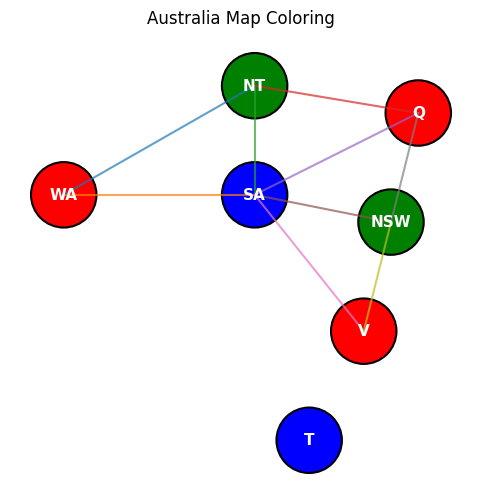

In [3]:
csp = australia_map_coloring()

# EXAMPLE 1: a VALID solution assignment
assignment_valid = {
    "WA":  "red",
    "NT":  "green",
    "SA":  "blue",
    "Q":   "red",
    "NSW": "green",
    "V":   "red",
    "T":   "blue",   # Tasmania is isolated; any color works
}

print("Variables:", csp.variables)
print("Domains:", csp.domains)
print("Neighbors of SA:", csp.neighbors["SA"])

print("Valid?", is_complete_and_valid(csp, assignment_valid))
plot_australia_coloring(assignment_valid)

Let's also check out an invalid assignment:

Valid? False


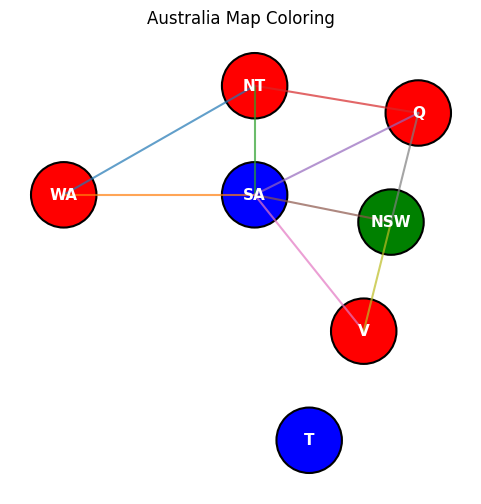

In [4]:
assignment_invalid = {
    "WA":  "red",
    "NT":  "red",    # <-- violates WA–NT ≠ constraint
    "SA":  "blue",
    "Q":   "red",
    "NSW": "green",
    "V":   "red",
    "T":   "blue",
}

print("Valid?", is_complete_and_valid(csp, assignment_invalid))  # should be False
plot_australia_coloring(assignment_invalid)                      # still plots; helps explain violations

### <a name="naive_search"></a> 1A. Naive Search with Variable Ordering (15 points)

Implement a brute-force **depth-first search** (DFS) that:
- assigns variables **in the given order** (`csp.variables`);
- **does not** check constraints until a **full** assignment is reached;
- returns **(solution_dict_or_None, steps_int)**, where **steps** = number of DFS nodes (partial assignments) visited.

<div class="alert alert-info">
Complete the code for `naive_search` below.
</div>

In [5]:
import queue
from re import search


def naive_search(csp: CSP) -> tuple[dict | None, int]:
    """
    Implement a brute-force DFS that:
      - assigns variables in the given order (csp.variables)
      - DOES NOT check constraints until a full assignment is built
      - returns a complete, valid assignment dict if one is found; else None
      - returns how many DFS nodes (partial assignments) were visited

    Returns:
      (solution_dict_or_None, steps_int)
    """
    order = list(csp.variables)

   





    
    def dfs(i: int, part_assign: dict) -> tuple[dict | None, int]:
      

      steps = 0
      node_count = 1

      if i == len(order):
        if is_complete_and_valid(csp=csp,assignment=part_assign):
          return(part_assign,node_count)
        else:
          return(None,node_count)
  

      var = order[i]
      
      # print(order)
      for domain_option in csp.domains[var]:
        part_assign[var] = domain_option
        solution, steps  = dfs(i+1, part_assign)
        node_count += steps
        if solution is not None:
          return (solution,node_count)
        del part_assign[var]

          
      return(None,node_count)

      
        


    # start the DFS at depth 0 with an empty assignment {}
    # (this initial call will count as visiting the first node)
    return dfs(0, {})  


# 1) build the CSP
csp = australia_map_coloring()

# 2) check the solution and counter
solution, steps = naive_search(csp)



    


Naive search (node count)
--------------------------------------
Valid solution found?: True
Nodes visited (DFS states): 627


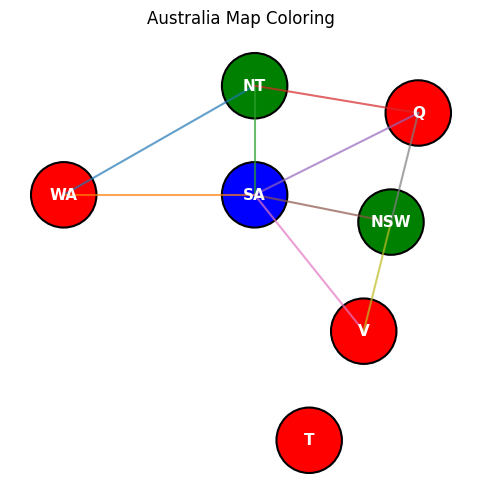

In [6]:
# 1) build the CSP
csp = australia_map_coloring()

# 2) check the solution and counter
solution, steps = naive_search(csp)
print("\nNaive search (node count)")
print("--------------------------------------")
print("Valid solution found?:", solution is not None and is_complete_and_valid(csp, solution))
print("Nodes visited (DFS states):", steps)

# 3) visualize
if solution:
    plot_australia_coloring(solution)

Even on an unsolvable version of the Australia map (2 colors instead of 3), Naive Search is very inefficient: it enumerates all possible colorings before concluding there is no solution.

In [7]:
# 1) build the impossible CSP
csp = australia_map_coloring_impossible()

# 2) check the solution and counter
solution_impossible, steps_impossible = naive_search(csp)
print("\nNaive search (node count)")
print("--------------------------------------")
print("Valid solution found?:", solution_impossible is not None and is_complete_and_valid(csp, solution_impossible))
print("Nodes visited (DFS states):", steps_impossible)


Naive search (node count)
--------------------------------------
Valid solution found?: False
Nodes visited (DFS states): 255


In [8]:
# Test 1
Grader.run_single_test_inline(TestPSet4, "test_01_naive_search", locals())

Test passed!!

.
----------------------------------------------------------------------
Ran 1 test in 0.008s

OK


### <a name="backtracking_search"></a> 1B. Backtracking Search (10 points)

Implement **backtracking search** that checks constraints **as soon as** you assign a variable (early failure):
- Same fixed order as naive search.
- After tentatively setting `part_assign[var] = val`, call `csp.is_consistent(var, part_assign)`.
- If consistent, recurse; otherwise, **backtrack** immediately.
- Return **(solution_dict_or_None, steps_int)** where **steps** counts DFS nodes like before.

<div class="alert alert-info">
Complete the code for `backtracking_search` below.
</div>

In [9]:
def backtracking_search(csp: CSP) -> tuple[dict | None, int]:
    """
    Implement backtracking search that:
      - assigns variables in the given order (csp.variables)
      - AFTER assigning a variable a value, IMMEDIATELY checks consistency for constraints involving it
      - returns a complete, valid assignment dict if one is found; else None
      - returns how many DFS nodes (partial assignments) were visited

    Returns:
      (solution_dict_or_None, steps_int)
    """
    order = list(csp.variables)

    def dfs(i: int, part_assign: dict) -> tuple[dict | None, int]:
      

      steps = 0
      node_count = 1

      if i == len(order):
        if is_complete_and_valid(csp=csp,assignment=part_assign):
          return(part_assign,node_count)
        else:
          return(None,node_count)
  

      var = order[i]

      print(var)
      
      # print(order)
      for domain_option in csp.domains[var]:
          part_assign[var] = domain_option
          if csp.is_consistent(var,part_assign):
            solution, steps  = dfs(i+1, part_assign)
            node_count += steps
            if solution is not None:
              return (solution,node_count)
          del part_assign[var]

          
      return(None,node_count)

      
        


    # start the DFS at depth 0 with an empty assignment {}
    # (this initial call will count as visiting the first node)
    return dfs(0, {})

# 1) build the CSP
csp = australia_map_coloring()

# 2) check the solution and counter
solution_bt, steps_bt = backtracking_search(csp)

WA
NT
SA
Q
NSW
V
T


Let's now run your implementation of Backtracking Search on the Australia problem:

WA
NT
SA
Q
NSW
V
T

Backtracking search
--------------------------------------
Valid solution found?: True
Backtracking solution: {'WA': 'red', 'NT': 'green', 'SA': 'blue', 'Q': 'red', 'NSW': 'green', 'V': 'red', 'T': 'red'}
Nodes visited: 8


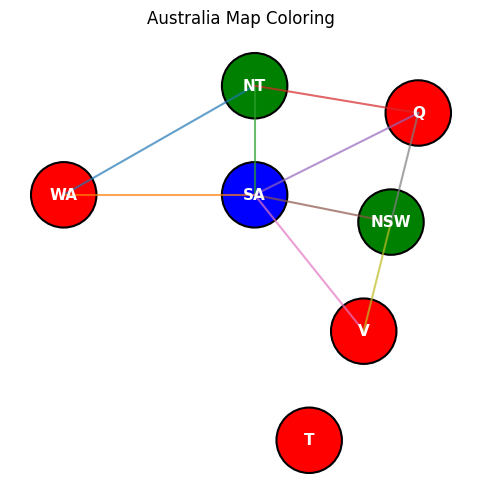

In [10]:
# 1) build the CSP
csp = australia_map_coloring()

# 2) check the solution and counter
solution_bt, steps_bt = backtracking_search(csp)
print("\nBacktracking search")
print("--------------------------------------")
print("Valid solution found?:", solution_bt is not None and is_complete_and_valid(csp, solution_bt))
print("Backtracking solution:", solution_bt)
print("Nodes visited:", steps_bt)

# 3) visualize
if solution_bt:
    plot_australia_coloring(solution_bt)

With this improvement, Backtracking Search is also much quicker at figuring out that a problem is unsolvable compared to Naive Search. By checking constraints as soon as a variable is assigned, it can prune inconsistent branches early.

In [11]:
# 1) build the impossible CSP
csp = australia_map_coloring_impossible()

# 2) check the solution and counter
solution_impossible_bt, steps_impossible_bt = backtracking_search(csp)
print("\Backtracking solution")
print("--------------------------------------")
print("Valid solution found?:", solution_impossible_bt is not None and is_complete_and_valid(csp, solution_impossible_bt))
print("Nodes visited:", steps_impossible_bt)

WA
NT
SA
NT
SA
\Backtracking solution
--------------------------------------
Valid solution found?: False
Nodes visited: 5


In [12]:
# Test 2
Grader.run_single_test_inline(TestPSet4, "test_02_backtracking_search", locals())

WA
NT
SA
Q
NSW
V
T
WA
NT
SA
NT
SA


Test passed!!

.
----------------------------------------------------------------------
Ran 1 test in 0.012s

OK


### <a name="forward_checking"></a> 1C. Forward Checking (20 points)

Implement **backtracking search with forward checking**:
- After assigning `var = val`, **prune** inconsistent values from **unassigned neighbors**’ domains.
- If any neighbor’s domain becomes empty, **backtrack** immediately.
- Carefully **restore** pruned values when backtracking.
- Return **(solution_dict_or_None, steps_int)** with the same node counting.

**What to implement**:
- `prune_neighbors(var, val, part_assign)` → returns `{neighbor: [removed_values...]}` or `None` (for wipeout).
- `restore(removed)` → put values back on backtrack.
- The DFS loop that applies + restores pruning.

<div class="alert alert-info">
Complete the code for `forward_checking_search` below.
</div>

In [13]:
def forward_checking_search(csp) -> tuple[dict | None, int]:
    """
    Implement backtracking search + forward checking that:
      - assigns variables in the given order (csp.variables)
      - after assigning var=val, PRUNE neighbors' domains by removing values
        that would violate any binary constraint with var
      - backtrack immediately if any neighbor domain becomes empty
      - restore pruned values on backtrack
      - returns (solution_dict_or_None, steps_int)

    Returns:
      (solution_dict_or_None, steps_int)
    """
    order = list(csp.variables)
    domains = {v: list(csp.domains[v]) for v in order}
    nbrs = {v: list(csp.neighbors[v]) for v in order}




    def prune_neighbors(var, val, part_assign) -> dict | None:
        """
        Forward-checking step:
            For each unassigned neighbor 'nbr' of 'var', remove values y in domains[nbr]
            for which some constraint between (var, nbr) would be violated by (var=val, nbr=y).
        Returns:
            - dict {nbr: [removed_values,...]} for restoration, or
            - None if a neighbor's domain becomes empty (wipeout -> immediate failure).
        """

        domain_cpy = domains.copy()

        # print("HELLO")
        # print(part_assign.keys())
        # print(nbrs[var])

  

        return_dict = {}
        


        for nbr in nbrs[var]:
          if nbr not in list(part_assign.keys()):
            # print(nbr)
            # print("needs pruning check")
            invalid_domain_options = []
            valid_count = 0
            

            for potential_domain_option in domain_cpy[nbr]:
              # print(potential_domain_option)
              part_assign[nbr] = potential_domain_option
              # print(csp.is_consistent(nbr,part_assign))
              if not csp.is_consistent(nbr,part_assign):
                # print("False puts me here")
                invalid_domain_options.append(potential_domain_option)
              else:
                valid_count += 1

              
              del part_assign[nbr]

              # print("valid count: ",valid_count)
            

            # print("out of the loop")

            if valid_count == 0:
              return None

            # print(invalid_domain_options)
            return_dict[nbr] = invalid_domain_options
            # print(return_dict)
        
        
        return return_dict


      

    def restore(removed):
        """
        Undo forward-checking domain pruning:
            For each variable listed in 'removed', add the pruned values back into its domain
        """

        # print("RESTORE")
        # print("Before")
        # print(domains )
        # print(removed)

        for key, value in removed.items():
          current_list = list(domains[key])
          for item in value:
            current_list.append(item)
          domains[key] = current_list
        # print(domains)
       


    def dfs(i: int, part_assign: dict) -> tuple[dict | None, int]:
      

      steps = 0
      node_count = 1

      if i == len(order):
        if is_complete_and_valid(csp=csp,assignment=part_assign):
          return(part_assign,node_count)
        else:
          return(None,node_count)
  

      #  things need to work on the actual domain variable 

      var = order[i]

      # print(var)
      
      # print(order)
      for domain_option in domains[var]:
          part_assign[var] = domain_option
          if csp.is_consistent(var,part_assign):
      
            pruned_options = prune_neighbors(var,domain_option,part_assign) # FIX to return the removed pieces for a specifc neighbor

            # do we remove the domain then 
            og_domains = domains.copy()


            print(pruned_options)
            if pruned_options is not None:

              # print("In pruning loop")
              for key, value in pruned_options.items():

                old_domain_list = domains[key]

                new_domain_list = [item for item in old_domain_list if item not in value]

                domains[key] = new_domain_list
          
         
              solution, steps  = dfs(i+1, part_assign)
              node_count += steps
              if solution is not None:
                return (solution,node_count)
              
              if pruned_options:
                # print("in restore func")
                restore(pruned_options)
          del part_assign[var]

        
          


          
      return(None,node_count)

      
      

    # start the DFS at depth 0 with an empty assignment {}
    # (this initial call will count as visiting the first node)
    return dfs(0, {})


# # 1) build the impossible CSP
# csp = australia_map_coloring_impossible()

# # 2) check the solution and counter
# solution_impossible_fc, steps_impossible_fc = forward_checking_search(csp)
# print("\Forward checking solution")
# print("--------------------------------------")
# print("Valid solution found?:", solution_impossible_fc is not None and is_complete_and_valid(csp, solution_impossible_fc))
# print("Nodes visited:", steps_impossible_fc)


Let's now run your implementation of Backtracking Search with Forward Checking on the Australia problem:

{'SA': ['red'], 'NT': ['red']}
{'SA': ['green'], 'Q': ['green']}
{'NSW': ['blue'], 'Q': ['blue'], 'V': ['blue']}
{'NSW': ['red']}
{'V': ['green']}
{}
{}
\Forward checking search
--------------------------------------
Valid solution found?: True
Forward checking solution: {'WA': 'red', 'NT': 'green', 'SA': 'blue', 'Q': 'red', 'NSW': 'green', 'V': 'red', 'T': 'red'}
Nodes visited: 8


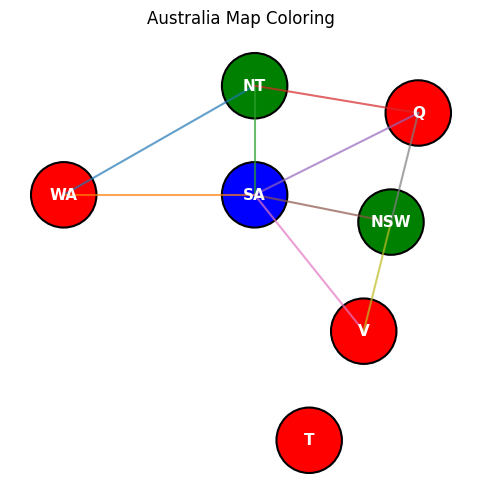

In [14]:
# 1) build the CSP
csp = australia_map_coloring()

# 2) check the solution and counter
solution_fc, steps_fc = forward_checking_search(csp)
print("\Forward checking search")
print("--------------------------------------")
print("Valid solution found?:", solution_fc is not None and is_complete_and_valid(csp, solution_fc))
print("Forward checking solution:", solution_fc)
print("Nodes visited:", steps_fc)

# 3) visualize
if solution_fc:
    plot_australia_coloring(solution_fc)

Forward Checking improves efficiency even further on unsolvable problems. By pruning inconsistent values from the domains of unassigned neighbors, it can detect dead-ends much earlier. This is especially helpful when every path is a dead-end, as it is in an unsolvable problem.

In [15]:
# 1) build the impossible CSP
csp = australia_map_coloring_impossible()

# 2) check the solution and counter
solution_impossible_fc, steps_impossible_fc = forward_checking_search(csp)
print("\Forward checking solution")
print("--------------------------------------")
print("Valid solution found?:", solution_impossible_fc is not None and is_complete_and_valid(csp, solution_impossible_fc))
print("Nodes visited:", steps_impossible_fc)

{'SA': ['red'], 'NT': ['red']}
None
{'SA': ['blue'], 'NT': ['blue']}
None
\Forward checking solution
--------------------------------------
Valid solution found?: False
Nodes visited: 3


In [16]:
# Test 3
Grader.run_single_test_inline(TestPSet4, "test_03_forward_checking", locals())

.
----------------------------------------------------------------------
Ran 1 test in 0.002s

OK


WA
NT
SA
Q
NSW
V
T
{'SA': ['red'], 'NT': ['red']}
{'SA': ['green'], 'Q': ['green']}
{'NSW': ['blue'], 'Q': ['blue'], 'V': ['blue']}
{'NSW': ['red']}
{'V': ['green']}
{}
{}
WA
NT
SA
NT
SA
{'SA': ['red'], 'NT': ['red']}
None
{'SA': ['blue'], 'NT': ['blue']}
None


### <a name="comparison"></a> 1D. Comparing algorithms on N-Queens (10 points)

Australia has few variables and sparse constraints, so improvements may look mild. N-Queens will help us compare and contrast our algorithms better. Let's create N-Queens and run our 3 algorithms above. Increase `n` gradually (e.g. 6, 8, 10) and note where naive search becomes infeasible.


=== N=6 Queens ===
Naive: steps=15316, valid=True
0
1
2
3
4
5
3
4
2
3
4
5
3
4
2
3
4
5
2
3
4
3
4
1
2
3
4
5
3
4
5
Backtracking: steps=32, valid=True
{1: [0, 1], 2: [0, 2], 3: [0, 3], 4: [0, 4], 5: [0, 5]}
{2: [1, 3], 3: [2, 4], 4: [2, 5], 5: [2]}
{3: [5], 4: [], 5: [1, 4]}
None
{3: [5], 4: [3], 5: []}
None
{2: [4, 3], 3: [1, 5], 4: [3], 5: [3]}
{3: [4], 4: [5], 5: [2]}
None
{3: [2], 4: [1], 5: [1, 4]}
None
{2: [5, 4, 3], 3: [4, 2], 4: [1], 5: [4]}
{3: [1], 4: [3], 5: [1]}
{4: [5], 5: [3]}
None
{2: [5, 4], 3: [5], 4: [2, 5], 5: [1]}
None
None
{1: [2, 0, 1], 2: [1, 3], 3: [1, 4], 4: [1, 5], 5: [1]}
{2: [4, 2], 3: [5, 3], 4: [3, 0], 5: [3]}
{3: [], 4: [], 5: [2, 5]}
None
{4: [], 5: [0]}
{5: []}
{}
Forward Checking: steps=18, valid=True


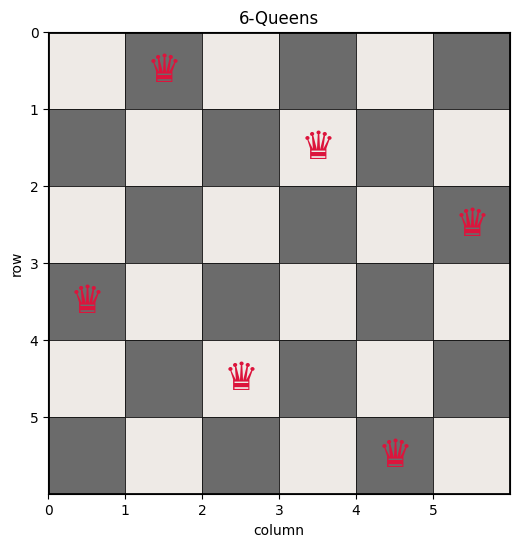

In [17]:
# Build N-Queens instance
n = 6 # Try out a few examples
print(f"\n=== N={n} Queens ===")
csp = n_queens_csp(n)

# Run naive
naive_sol, naive_steps = naive_search(csp)
print(f"Naive: steps={naive_steps}, valid={is_complete_and_valid(csp, naive_sol or {})}")

# Run backtracking
bt_sol, bt_steps = backtracking_search(csp)
print(f"Backtracking: steps={bt_steps}, valid={is_complete_and_valid(csp, bt_sol or {})}")

# Run Forward Checking
fc_sol, fc_steps = forward_checking_search(csp)
print(f"Forward Checking: steps={fc_steps}, valid={is_complete_and_valid(csp, fc_sol or {})}")

# Plot the forward-checking solution (if found)
if fc_sol:
    plot_n_queens(fc_sol, n=n, invert_rows=True)

We can even plot the number of nodes expanded with increasing `n`. Run all three algorithms (naive, backtracking, forward checking) on N-Queens for a range of N values (e.g. 1–8). Plot N vs. nodes visited for each algorithm on the same plot the cell below.

**Hint:** Not seeing a line for Backtracking? It's probably covered by the Forward Checking line - try plotting with a log y-scale!


=== N=1 Queens ===
0
{}

=== N=2 Queens ===
0
1
1
None
None

=== N=3 Queens ===
0
1
2
1
1
2
{1: [0, 1], 2: [0, 2]}
None
None
{1: [2, 1], 2: [0, 2]}
None

=== N=4 Queens ===
0
1
2
2
3
1
2
3
{1: [0, 1], 2: [0, 2], 3: [0, 3]}
None
{2: [3], 3: [1]}
None
{1: [2, 0, 1], 2: [1, 3], 3: [1]}
{2: [2], 3: [3]}
{3: [0]}
{}

=== N=5 Queens ===
0
1
2
3
4
{1: [0, 1], 2: [0, 2], 3: [0, 3], 4: [0, 4]}
{2: [1, 3], 3: [2, 4], 4: [2]}
{3: [], 4: []}
{4: [1]}
{}

=== N=6 Queens ===
0
1
2
3
4
5
3
4
2
3
4
5
3
4
2
3
4
5
2
3
4
3
4
1
2
3
4
5
3
4
5
{1: [0, 1], 2: [0, 2], 3: [0, 3], 4: [0, 4], 5: [0, 5]}
{2: [1, 3], 3: [2, 4], 4: [2, 5], 5: [2]}
{3: [5], 4: [], 5: [1, 4]}
None
{3: [5], 4: [3], 5: []}
None
{2: [4, 3], 3: [1, 5], 4: [3], 5: [3]}
{3: [4], 4: [5], 5: [2]}
None
{3: [2], 4: [1], 5: [1, 4]}
None
{2: [5, 4, 3], 3: [4, 2], 4: [1], 5: [4]}
{3: [1], 4: [3], 5: [1]}
{4: [5], 5: [3]}
None
{2: [5, 4], 3: [5], 4: [2, 5], 5: [1]}
None
None
{1: [2, 0, 1], 2: [1, 3], 3: [1, 4], 4: [1, 5], 5: [1]}
{2: [4, 2], 3: [

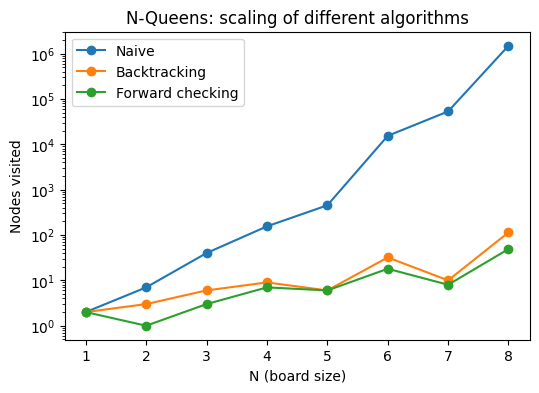

In [18]:
nn_steps_ll = []
bt_steps_ll = []
fc_steps_ll = []


for i in range(1,9):

    n = i # Try out a few examples
    print(f"\n=== N={n} Queens ===")
    csp = n_queens_csp(n)

    # Run naive
    naive_sol, naive_steps = naive_search(csp)
    nn_steps_ll.append(naive_steps)


    # Run backtracking
    bt_sol, bt_steps = backtracking_search(csp)
    bt_steps_ll.append(bt_steps)
 

    # Run Forward Checking
    fc_sol, fc_steps = forward_checking_search(csp)
    fc_steps_ll.append(fc_steps)


plt.figure(figsize=(6,4))
plt.plot(range(1,9), nn_steps_ll, marker="o", label="Naive")
plt.plot(range(1,9), bt_steps_ll, marker="o", label="Backtracking")
plt.plot(range(1,9), fc_steps_ll, marker="o", label="Forward checking")
plt.yscale("log")
plt.xlabel("N (board size)")
plt.ylabel("Nodes visited")
plt.title("N-Queens: scaling of different algorithms")
plt.legend()
plt.savefig("nqueens_scaling.png")
plt.show()

**Now answer the following questions:**
1. How do the curves differ across algorithms? Which one scales worst, and which scales best?  
2. Why does forward checking give larger benefits on N-Queens than on Australia?  

<div class="alert alert-info">
Write your answer in the cell below this one.
</div>

Its interesting that forward checking and backtracking are quite similar while naive grows exponentially. Forward checking I assume scales the best.

FC works better N queens becuase the state space is so much larger where the pruning has an actual impact.

## <a name="sudoku"></a> 2. Sudoku: Forward Checking vs. Backtracking [AI-enabled] (15 points)

In this section you will use an LLM (Claude, ChatGPT, etc.) to encode Sudoku as a CSP in the framework from Section 1, design a puzzle on which forward checking and backtracking behave very differently, and visualize why.

A Sudoku puzzle is a 9×9 grid. Each row, each column, and each of the nine 3×3 boxes must contain the digits 1–9 exactly once. We represent a puzzle as a 9×9 array of integers in which `0` marks an empty cell. Below we provide an example puzzle and a `plot_sudoku` helper for drawing puzzles and solutions.

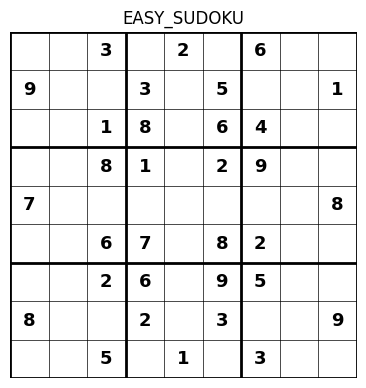

In [47]:
# ---------- Sudoku helpers ----------

EASY_SUDOKU = [
    [0, 0, 3, 0, 2, 0, 6, 0, 0],
    [9, 0, 0, 3, 0, 5, 0, 0, 1],
    [0, 0, 1, 8, 0, 6, 4, 0, 0],
    [0, 0, 8, 1, 0, 2, 9, 0, 0],
    [7, 0, 0, 0, 0, 0, 0, 0, 8],
    [0, 0, 6, 7, 0, 8, 2, 0, 0],
    [0, 0, 2, 6, 0, 9, 5, 0, 0],
    [8, 0, 0, 2, 0, 3, 0, 0, 9],
    [0, 0, 5, 0, 1, 0, 3, 0, 0],
]

def plot_sudoku(grid, solution=None, ax=None, title=None):
    """
    Draw a Sudoku puzzle, optionally with a solution filled in.

    Args:
      grid: 9x9 array of ints, 0 for an empty cell. Clues are drawn in bold black.
      solution (dict): optional {(row, col): digit}; digits in empty cells are drawn in blue.
      ax: optional matplotlib Axes to draw on.
      title (str): optional title.

    Returns:
      the matplotlib Axes
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(4.5, 4.5))
    for k in range(10):
        lw = 2 if k % 3 == 0 else 0.5
        ax.plot([0, 9], [k, k], color="black", lw=lw)
        ax.plot([k, k], [0, 9], color="black", lw=lw)
    for r in range(9):
        for c in range(9):
            if grid[r][c]:
                ax.text(c + 0.5, r + 0.5, str(grid[r][c]), ha="center", va="center",
                        fontsize=13, weight="bold")
            elif solution and (r, c) in solution:
                ax.text(c + 0.5, r + 0.5, str(solution[(r, c)]), ha="center", va="center",
                        fontsize=13, color="tab:blue")
    ax.set_xlim(0, 9); ax.set_ylim(9, 0)
    ax.set_aspect("equal"); ax.axis("off")
    if title:
        ax.set_title(title)
    return ax

plot_sudoku(EASY_SUDOKU, title="EASY_SUDOKU")
plt.show()

### <a name="sudoku_csp"></a> 2A. Encoding Sudoku as a CSP [AI-enabled] (3 points)

Use an LLM to implement `sudoku_csp(grid)`, which converts a puzzle into a `CSP` that your solvers from Section 1 can solve. Follow these conventions exactly, because the order of the variables and values determines how many nodes your solvers visit:

- The `grid` is a 9×9 list of lists or NumPy array of integers from 0 to 9, where 0 marks an empty cell.
- One per cell, named by the tuple `(row, col)` and listed in row-major order: `(0, 0), (0, 1), ..., (0, 8), (1, 0), ..., (8, 8)`.
- A clue cell's domain is a list containing only its digit. An empty cell's domain is `[1, 2, ..., 9]`, in ascending order.
- A `BinaryConstraint` requiring different digits between every pair of cells that share a row, column, or 3×3 box, and no other constraints.

<div class="alert alert-info">
Include your LLM-generated implementation of <code>sudoku_csp</code> below.
</div>

In [57]:
def sudoku_csp(grid) -> CSP:
    """
    Construct the Sudoku CSP for a puzzle.
 
    Args:
      grid: 9x9 list of lists or np.ndarray of ints; 0 marks an empty cell.
 
    Returns:
      CSP object with a variable (row, col) per cell in row-major order, domain
      [digit] for each clue and [1, ..., 9] for each empty cell, and a
      "different digits" BinaryConstraint between every pair of cells that
      share a row, column, or 3x3 box.
    """
    grid = [[int(x) for x in row] for row in grid]
 
    # One variable per cell, row-major order
    variables = [(r, c) for r in range(9) for c in range(9)]
 
    # Clue -> singleton domain; empty -> [1..9] ascending
    domains = {(r, c): [grid[r][c]] if grid[r][c] != 0 else list(range(1, 10))
               for (r, c) in variables}
 
    def same_unit(a, b):
        return (a[0] == b[0] or a[1] == b[1] or
                (a[0] // 3 == b[0] // 3 and a[1] // 3 == b[1] // 3))
 
    # Exactly one "different digits" constraint per pair of peers (810 total)
    constraints = []
    for i, a in enumerate(variables):
        for b in variables[i + 1:]:
            if same_unit(a, b):
                constraints.append(BinaryConstraint(a, b, lambda x, y: x != y))
 
    # ADAPT THIS LINE to your Section 1 CSP constructor if it differs

    print(variables)
    print(domains)
    print(constraints)
    csp = CSP(variables, domains)
    for constraint in constraints:
        csp.add_constraint(constraint)
    return csp
    # return CSP(variables, domains, constraints)

Let's build the CSP for `EASY_SUDOKU` and solve it with your forward checking search:

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (7, 0), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (8, 0), (8, 1), (8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (8, 8)]
{(0, 0): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 1): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 2): [3], (0, 3): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 4): [2], (0, 5): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 6): [6], (0, 7): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 8): [1, 2, 3, 4, 5, 6, 7, 8, 9], (1, 0): [9], (1, 1): [1, 2, 3, 4, 5, 6, 7, 8, 9], (1, 2): [1, 2, 3, 4, 5, 6, 7, 8, 9], (1

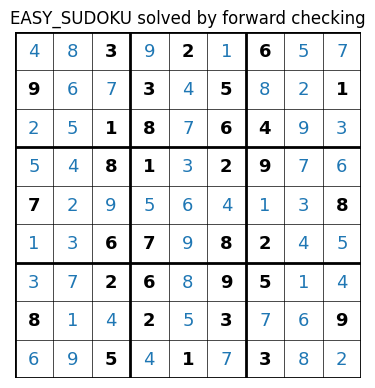

In [58]:
csp = sudoku_csp(EASY_SUDOKU)
n_constraints = sum(len(cs) for cs in csp.constraints.values()) // 2
print(f"{len(csp.variables)} variables, {n_constraints} BinaryConstraint objects")

fc_sol, fc_steps = forward_checking_search(csp)
print(f"Forward checking: steps={fc_steps}, valid={is_complete_and_valid(csp, fc_sol or {})}")
plot_sudoku(EASY_SUDOKU, fc_sol, title="EASY_SUDOKU solved by forward checking")
plt.show()

# Backtracking also solves this puzzle, but it visits about a million nodes
# (roughly 15 seconds). Uncomment to try it:
# bt_sol, bt_steps = backtracking_search(csp)
# print(f"Backtracking: steps={bt_steps}, valid={is_complete_and_valid(csp, bt_sol or {})}")

In [59]:
# Test 4
Grader.run_single_test_inline(TestPSet4, "test_04_sudoku_csp", locals())

ValueError: no such test method in <class 'principles_of_autonomy.notebook_tests.pset_4.TestPSet4'>: test_04_sudoku_csp

### <a name="adversarial_sudoku"></a> 2B. Design a Puzzle That Separates Forward Checking from Backtracking [AI-enabled] (6 points)

On `EASY_SUDOKU`, forward checking visits a few hundred nodes while backtracking visits nearly a million. Your task is to use an LLM to design a puzzle on which the gap is larger.

Implement `return_adversarial_sudoku()` so that it returns a 9×9 puzzle (0 for empty cells) that satisfies all of the following:

1. The puzzle has *exactly one* solution.
2. The puzzle has *at least 40* clues.
3. Forward checking visits *at most 20,000* nodes.
4. Backtracking visits *at least 1,000,000* nodes.

Both searches use the encoding from 2A. The variables are processed in row-major order, values in ascending order, and nodes counted as in 1B and 1C.

The autograder checks conditions 3 and 4 with internal implementations of 1B and 1C that stop counting at those limits, so it never waits for backtracking to finish. 

<div class="alert alert-info">
Include your puzzle below, along with any LLM-generated code you used to find it.
</div>

In [60]:

def return_adversarial_sudoku():
    """
    Returns:
      grid: 9x9 list of lists of ints (0 for empty cells) that meets the four
      conditions in 2B.
    """
    return [
        [0, 0, 0, 6, 0, 4, 3, 2, 0],
        [0, 0, 0, 7, 0, 0, 0, 5, 0],
        [5, 0, 0, 0, 2, 0, 0, 0, 0],
        [0, 0, 5, 9, 7, 2, 1, 6, 8],
        [0, 0, 0, 0, 0, 0, 5, 0, 3],
        [8, 7, 6, 3, 1, 5, 9, 4, 2],
        [7, 2, 8, 0, 4, 1, 0, 0, 9],
        [0, 5, 0, 0, 3, 0, 0, 1, 0],
        [1, 3, 9, 0, 6, 7, 4, 0, 5],
    ]

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (7, 0), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (8, 0), (8, 1), (8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (8, 8)]
{(0, 0): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 1): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 2): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 3): [6], (0, 4): [1, 2, 3, 4, 5, 6, 7, 8, 9], (0, 5): [4], (0, 6): [3], (0, 7): [2], (0, 8): [1, 2, 3, 4, 5, 6, 7, 8, 9], (1, 0): [1, 2, 3, 4, 5, 6, 7, 8, 9], (1, 1): [1, 2, 3, 4, 5, 6, 7, 8, 9], (1, 2): [1, 2, 3, 4, 5, 6, 7, 8, 9], (1

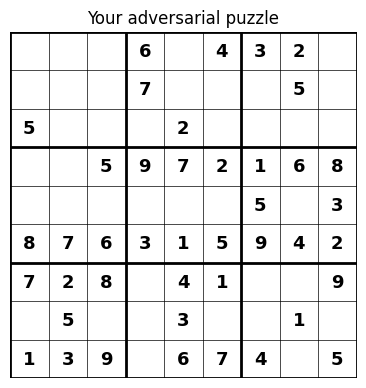

In [61]:
adversarial = return_adversarial_sudoku()
csp = sudoku_csp(adversarial)
print(f"Clues: {sum(1 for row in adversarial for x in row if x)}")

fc_sol, fc_steps = forward_checking_search(csp)
print(f"Forward checking: steps={fc_steps}, valid={is_complete_and_valid(csp, fc_sol or {})}")
plot_sudoku(adversarial, title="Your adversarial puzzle")
plt.show()

In [62]:
# Test 5
Grader.run_single_test_inline(TestPSet4, "test_05_adversarial_sudoku", locals())

ValueError: no such test method in <class 'principles_of_autonomy.notebook_tests.pset_4.TestPSet4'>: test_05_adversarial_sudoku

### <a name="sudoku_viz"></a> 2C. Visualize Why Backtracking Struggles [AI-enabled] (6 points)

Using an LLM and `matplotlib`, create a visualization that explains why backtracking visits so many more nodes than forward checking on your puzzle from 2B. Then explain the result in the cell below your visualization.

Some suggestions for visualizations:
- a heatmap of how many values each algorithm tries in each cell,
- the number of nodes visited at each search depth,
- the search depth at which each dead end is detected.

<div class="alert alert-info">
Include the code to generate your visualization (which should appear immediately underneath the cell) below.
</div>

Backtracking (profiled): 2,000,000 nodes; forward checking: 522 nodes


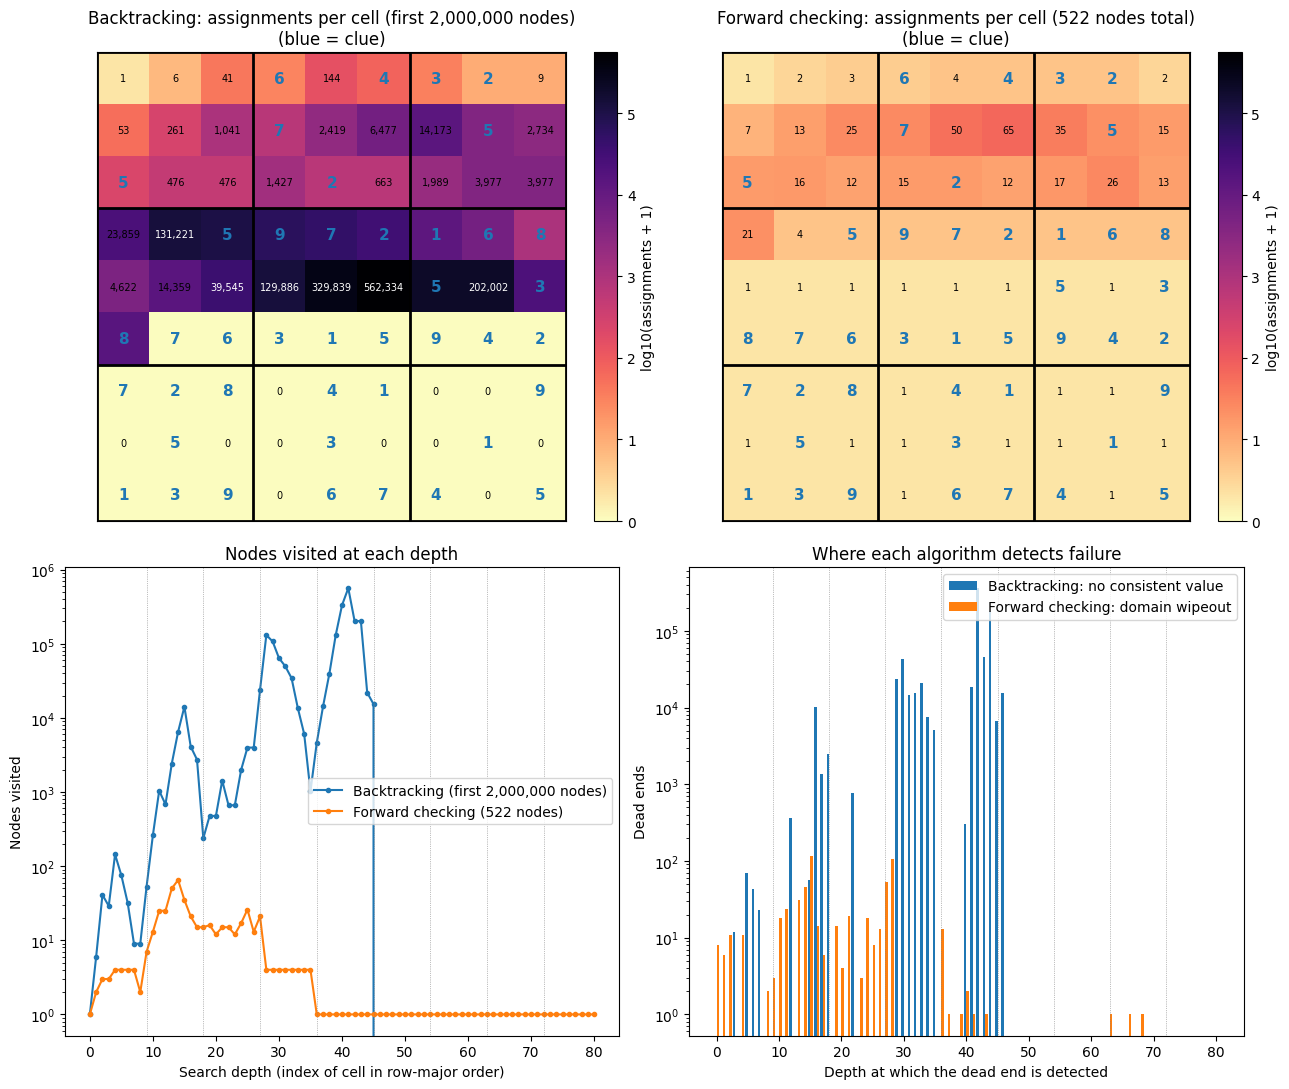

In [63]:

import sys
from collections import Counter
sys.setrecursionlimit(10000)
 
def _setup(grid):
    cells = [(r, c) for r in range(9) for c in range(9)]
    nbrs = {v: [w for w in cells if w != v and (w[0] == v[0] or w[1] == v[1] or
                (w[0] // 3 == v[0] // 3 and w[1] // 3 == v[1] // 3))] for v in cells}
    doms = {(r, c): [grid[r][c]] if grid[r][c] else list(range(1, 10)) for (r, c) in cells}
    return cells, nbrs, doms
 
def instrumented_backtracking(grid, node_cap=2_000_000):
    cells, nbrs, doms = _setup(grid)
    tries = np.zeros((9, 9)); depth_nodes = Counter(); dead_ends = Counter()
    asg, n = {}, [0]
    def rec(i):
        if i == 81: return True
        v = cells[i]; extended = False
        for x in doms[v]:
            if n[0] >= node_cap: return False
            if any(asg.get(w) == x for w in nbrs[v]): continue
            n[0] += 1; tries[v] += 1; depth_nodes[i] += 1; extended = True
            asg[v] = x
            if rec(i + 1): return True
            del asg[v]
        if not extended: dead_ends[i] += 1   # no value fits: failure detected at depth i
        return False
    rec(0)
    return tries, depth_nodes, dead_ends, n[0]
 
def instrumented_forward_checking(grid):
    cells, nbrs, doms = _setup(grid)
    tries = np.zeros((9, 9)); depth_nodes = Counter(); dead_ends = Counter()
    asg, n = {}, [0]
    def rec(i, dom):
        if i == 81: return True
        v = cells[i]
        for x in dom[v]:
            nd = {w: list(d) for w, d in dom.items()}; nd[v] = [x]; ok = True
            for w in nbrs[v]:
                if w not in asg and x in nd[w]:
                    nd[w].remove(x)
                    if not nd[w]: ok = False; break
            if not ok:
                dead_ends[i] += 1           # wipeout detected immediately at depth i
                continue
            n[0] += 1; tries[v] += 1; depth_nodes[i] += 1
            asg[v] = x
            if rec(i + 1, nd): return True
            del asg[v]
        return False
    rec(0, doms)
    return tries, depth_nodes, dead_ends, n[0]
 
BT_CAP = 2_000_000   # full backtracking run is ~56M nodes; we profile the first 2M
bt_tries, bt_depth, bt_dead, bt_n = instrumented_backtracking(adversarial, BT_CAP)
fc_tries, fc_depth, fc_dead, fc_n = instrumented_forward_checking(adversarial)
 
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
clue_mask = np.array(adversarial) > 0
 
for ax, tries, name, n in [(axes[0, 0], bt_tries, "Backtracking", bt_n),
                           (axes[0, 1], fc_tries, "Forward checking", fc_n)]:
    im = ax.imshow(np.log10(tries + 1), cmap="magma_r", vmin=0, vmax=np.log10(bt_tries.max() + 1))
    for r in range(9):
        for c in range(9):
            txt = str(adversarial[r][c]) if clue_mask[r, c] else f"{int(tries[r, c]):,}"
            ax.text(c, r, txt, ha="center", va="center", fontsize=7 if not clue_mask[r, c] else 11,
                    weight="bold" if clue_mask[r, c] else "normal",
                    color="tab:blue" if clue_mask[r, c] else ("white" if tries[r, c] > 3e4 else "black"))
    for k in range(-1, 9, 3):
        ax.axhline(k + 0.5, color="k", lw=2); ax.axvline(k + 0.5, color="k", lw=2)
    ax.set_xticks([]); ax.set_yticks([])
    suffix = f" (first {n:,} nodes)" if name == "Backtracking" else f" ({n:,} nodes total)"
    ax.set_title(f"{name}: assignments per cell{suffix}\n(blue = clue)")
    fig.colorbar(im, ax=ax, fraction=0.046, label="log10(assignments + 1)")
 
ax = axes[1, 0]
d = np.arange(81)
ax.semilogy(d, [bt_depth[i] for i in d], "-o", ms=3, label=f"Backtracking (first {bt_n:,} nodes)")
ax.semilogy(d, [fc_depth[i] for i in d], "-o", ms=3, label=f"Forward checking ({fc_n:,} nodes)")
for k in range(9, 81, 9): ax.axvline(k, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Search depth (index of cell in row-major order)"); ax.set_ylabel("Nodes visited")
ax.set_title("Nodes visited at each depth"); ax.legend()
 
ax = axes[1, 1]
ax.bar(d - 0.2, [bt_dead[i] for i in d], width=0.4, label="Backtracking: no consistent value")
ax.bar(d + 0.2, [fc_dead[i] for i in d], width=0.4, label="Forward checking: domain wipeout")
ax.set_yscale("log")
for k in range(9, 81, 9): ax.axvline(k, color="gray", lw=0.5, ls=":")
ax.set_xlabel("Depth at which the dead end is detected"); ax.set_ylabel("Dead ends")
ax.set_title("Where each algorithm detects failure"); ax.legend()
 
plt.tight_layout()
print(f"Backtracking (profiled): {bt_n:,} nodes; forward checking: {fc_n:,} nodes")
plt.show()
 

## 3. <a name="classical_planning"></a> Classical Planning (25 points) 

In this section, we shift to **classical planning**. You will get hands-on practice with running a planner on simple problems, writing your own PDDL domain and problem, and comparing heuristics and search strategies.

As before, we'll scaffold most of the setup so you can focus on the core planning ideas:


In [19]:
import os
import time
import tempfile
from pyperplan.pddl.parser import Parser
from pyperplan import grounding, planner

# This uses TYPING
BLOCKS_DOMAIN = """(define (domain blocks)
    (:requirements :strips :typing)
    (:types block)
    (:predicates
        (on ?x - block ?y - block)
        (ontable ?x - block)
        (clear ?x - block)
        (handempty)
        (holding ?x - block)
    )

    (:action pick-up
        :parameters (?x - block)
        :precondition (and
            (clear ?x)
            (ontable ?x)
            (handempty)
        )
        :effect (and
            (not (ontable ?x))
            (not (clear ?x))
            (not (handempty))
            (holding ?x)
        )
    )

    (:action put-down
        :parameters (?x - block)
        :precondition (and
            (holding ?x)
        )
        :effect (and
            (not (holding ?x))
            (clear ?x)
            (handempty)
            (ontable ?x))
        )

    (:action stack
        :parameters (?x - block ?y - block)
        :precondition (and
            (holding ?x)
            (clear ?y)
        )
        :effect (and
            (not (holding ?x))
            (not (clear ?y))
            (clear ?x)
            (handempty)
            (on ?x ?y)
        )
    )

    (:action unstack
        :parameters (?x - block ?y - block)
        :precondition (and
            (on ?x ?y)
            (clear ?x)
            (handempty)
        )
        :effect (and
            (holding ?x)
            (clear ?y)
            (not (clear ?x))
            (not (handempty))
            (not (on ?x ?y))
        )
    )
)
"""

# This uses TYPING
BLOCKS_PROBLEM = """(define (problem blocks)
    (:domain blocks)
    (:objects
        d - block
        b - block
        a - block
        c - block
    )
    (:init
        (clear a)
        (on a b)
        (on b c)
        (on c d)
        (ontable d)
        (handempty)
    )
    (:goal (and (on d c) (on c b) (on b a)))
)
"""

# The BW domain does not use TYPING
BW_BLOCKS_DOMAIN = """(define (domain prodigy-bw)
  (:requirements :strips)
  (:predicates (on ?x ?y)
               (ontable ?x)
               (clear ?x)
               (handempty)
               (holding ?x)
               )
  (:action pick-up
             :parameters (?ob1)
             :precondition (and (clear ?ob1) (ontable ?ob1) (handempty))
             :effect
             (and (not (ontable ?ob1))
                   (not (clear ?ob1))
                   (not (handempty))
                   (holding ?ob1)))
  (:action put-down
             :parameters (?ob)
             :precondition (holding ?ob)
             :effect
             (and (not (holding ?ob))
                   (clear ?ob)
                   (handempty)
                   (ontable ?ob)))
  (:action stack
             :parameters (?sob ?sunderob)
             :precondition (and (holding ?sob) (clear ?sunderob))
             :effect
             (and (not (holding ?sob))
                   (not (clear ?sunderob))
                   (clear ?sob)
                   (handempty)
                   (on ?sob ?sunderob)))
  (:action unstack
             :parameters (?sob ?sunderob)
             :precondition (and (on ?sob ?sunderob) (clear ?sob) (handempty))
             :effect
             (and (holding ?sob)
                   (clear ?sunderob)
                   (not (clear ?sob))
                   (not (handempty))
                   (not (on ?sob ?sunderob)))))
"""


def get_task_definition_str(domain_pddl_str, problem_pddl_str):
    """Get Pyperplan task definition from PDDL domain and problem.

    This function is a lightweight wrapper around Pyperplan.

    Args:
      domain_pddl_str: A str, the contents of a domain.pddl file.
      problem_pddl_str: A str, the contents of a problem.pddl file.

    Returns:
      task: a structure defining the problem
    """
    # Parsing the PDDL
    domain_file = tempfile.NamedTemporaryFile(delete=False)
    problem_file = tempfile.NamedTemporaryFile(delete=False)
    with open(domain_file.name, 'w') as f:
        f.write(domain_pddl_str)
    with open(problem_file.name, 'w') as f:
        f.write(problem_pddl_str)
    parser = Parser(domain_file.name, problem_file.name)
    domain = parser.parse_domain()
    problem = parser.parse_problem(domain)
    os.remove(domain_file.name)
    os.remove(problem_file.name)

    # Ground the PDDL
    task = grounding.ground(problem)
    return task


def run_planning(domain_pddl_str,
                 problem_pddl_str,
                 search_alg_name,
                 heuristic_name=None,
                 return_time=False):
    """Plan a sequence of actions to solve the given PDDL problem.

    This function is a lightweight wrapper around pyperplan.

    Args:
      domain_pddl_str: A str, the contents of a domain.pddl file.
      problem_pddl_str: A str, the contents of a problem.pddl file.
      search_alg_name: A str, the name of a search algorithm in
        pyperplan. Options: astar, wastar, gbf, bfs, ehs, ids, sat.
      heuristic_name: A str, the name of a heuristic in pyperplan.
        Options: blind, hadd, hmax, hsa, hff, lmcut, landmark.
      return_time:  Bool. Set to `True` to return the planning time.

    Returns:
      plan: A list of actions; each action is a pyperplan Operator.
    """
    # Ground the PDDL
    task = get_task_definition_str(domain_pddl_str, problem_pddl_str)

    # Get the search alg
    search_alg = planner.SEARCHES[search_alg_name]

    if heuristic_name is None:
        if not return_time:
            return search_alg(task)
        start_time = time.time()
        plan = search_alg(task)
        plan_time = time.time() - start_time
        return plan, plan_time

    # Get the heuristic
    heuristic = planner.HEURISTICS[heuristic_name](task)

    # Run planning
    start_time = time.time()
    plan = search_alg(task, heuristic)
    plan_time = time.time() - start_time

    if return_time:
        return plan, plan_time
    return plan


def h_add_test(prob_str, expected_h):
    task = get_task_definition_str(BW_BLOCKS_DOMAIN, prob_str)
    h = h_add(task)
    assert h == expected_h, f"Expected h={expected_h}, but got {h}."
    return h


def h_ff_test(prob_str, expected_h):
    task = get_task_definition_str(BW_BLOCKS_DOMAIN, prob_str)
    h = h_ff(task)
    assert h == expected_h, f"Expected h={expected_h}, but got {h}."

### <a name="warmup"></a> 3A. Warming up with Pyperplan (5 points)

In this homework, we will be using a Python PDDL planner called `pyperplan`. Let's warm up by using `pyperplan` to solve a given blocks PDDL problem.

Use `run_planning` to find a plan for the blocks problem defined above (`BLOCKS_DOMAIN`, `BLOCKS_PROBLEM`).

The `run_planning` function takes in a PDDL domain string, a PDDL problem string, the name of a search algorithm, and the name of a heuristic (if the search algorithm is informed) or a customized heuristic class. It then uses the Python planning library `pyperplan` to find a plan.

The plan returned by `run_planning` is a list of pyperplan Operators. You should not need to manipulate these data structures directly in this homework, but if you are curious about the definition, see [here](https://github.com/aibasel/pyperplan/blob/master/pyperplan/task.py#L23).

The search algs available in pyperplan are: `astar, wastar, gbf, bfs, ehs, ids, sat`. The heuristics available in pyperplan are: `blind, hadd, hmax, hsa, hff, lmcut, landmark`.

For this question, use the `astar` search algorithm with the `hadd` heuristic.

For reference, our solution is **1** line(s) of code.


In [21]:



def planning_warmup():
    '''Use run_planning to find a plan for the blocks problem defined at the
    top of the colab file (BLOCKS_DOMAIN, BLOCKS_PROBLEM).

      Use the astar search algorithm with the hadd heuristic.

    Returns:
      plan: A list of actions; each action is a pyperplan Operator.
    '''
    plan = run_planning(domain_pddl_str=BLOCKS_DOMAIN,problem_pddl_str=BLOCKS_PROBLEM,search_alg_name="astar",heuristic_name="hadd")
    print(plan)
    return plan
    

In [22]:
# Test 8
Grader.run_single_test_inline(TestPSet4, "test_08_planning_warmup", locals())

[<Op (unstack a b)>, <Op (put-down a)>, <Op (unstack b c)>, <Op (stack b a)>, <Op (unstack c d)>, <Op (stack c b)>, <Op (pick-up d)>, <Op (stack d c)>]


Test passed!!

.
----------------------------------------------------------------------
Ran 1 test in 0.015s

OK


### <a name="pddl"></a> 3B. Fill in the Blanks (10 points)

You've received PDDL domain and problem strings from your boss and you need to make a plan, pronto! Unfortunately, some of the PDDL is missing.

Here's what you know. What you're trying to model is a newspaper delivery robot. The robot starts out at a "home base" where there are papers that it can pick up. The robot can hold arbitrarily many papers at once. It can then move around to different locations and deliver papers.

Not all locations want a paper -- the goal is to satisfy all the locations that do want a paper.

You also know:
* There are 6 locations in addition to 1 for the homebase. Locations 1, 2, 3, and 4 want paper; locations 5 and 6 do not.
* There are 8 papers at the homebase.
* The robot is initially at the homebase with no papers packed.

Use this description to complete the PDDL domain and problem. You can assume the PDDL planner will find the optimal solution.

If you are running into issues writing or debugging the PDDL you can check out this online PDDL editor, which comes with a built-in planner: [editor.planning.domains](http://editor.planning.domains). To use the editor, you can create two files, one for the domain and one for the problem. You can then click "Solve" at the top to use the built-in planner.

For a general reference on PDDL, check out [planning.wiki](https://planning.wiki/). Note that the PDDL features supported by pyperplan are very limited: types and constants are supported, but that's about it. If you want to make a domain that involves more advanced features, you can try the built-in planner at [editor.planning.domains](http://editor.planning.domains), or you can use any other PDDL planner of your choosing.

Debugging PDDL can be painful. The online editor at [editor.planning.domains](http://editor.planning.domains) is helpful: pay attention to the syntax highlighting and to the line numbers in error messages that result from trying to Solve. To debug, you can also comment out multiple lines of your files by highlighting and using `Ctrl + /` or `Cmd + /`. Common issues to watch out for include:
* A predicate is not defined in the domain file
* A variable name does not start with a question mark
* An illegal character is used (we recommended sticking with alphanumeric characters, dashes, or underscores; and don't start any names with numbers)
* An operator is missing a parameter (in general, the parameters should be exactly the variables that are used anywhere in the operator's preconditions or effects)
* An operator is missing a necessary precondition or effect
* Using negated preconditions, which are not allowed in basic Strips

If you get stuck debugging your PDDL file for more than 10-15 min, please reach out and we'll help!

Look through the following file, find the TODOs and complete the necessary PDDL terms. 

In [25]:
def pddl_warmup():
    '''Creates a PDDL domain and problem strs for newspaper delivery (uses
    TYPING).

    Returns:
      domain: str
      problem: str
    '''
    domain_str = '''(define (domain newspapers)
    (:requirements :strips :typing)
    (:types loc paper)
    (:predicates
      (at ?loc - loc)
      (isHomeBase ?loc - loc)
      (carrying ?paper - paper)
      (wantsPaper ?loc - loc)
      (unpacked ?paper - paper)
      (satisfied ?loc - loc)
      
    )

    (:action pick-up
      :parameters (?paper - paper ?loc - loc)    ; TODO: Uncomment by removing the ';' and add missing parameters!
      :precondition (and
        (at ?loc)
        (isHomeBase ?loc)
        (unpacked ?paper)
      )
      :effect (and
        (not (unpacked ?paper))
        (carrying ?paper)
      )
    )

    (:action move
      :parameters (?from - loc ?to - loc)
      :precondition (and
        (at ?from) 
      )
      :effect (and
        (not (at ?from))
        (at ?to)
      )
    )

    (:action deliver
      :parameters (?paper - paper ?loc - loc)
      :precondition (and
        (at ?loc)
        (wantsPaper ?loc)
        (carrying ?paper)
      )
      :effect (and
        (not (carrying ?paper))
        (satisfied ?loc)
        
      )
    )

)'''

    problem_str = '''(define (problem newspapers1) (:domain newspapers)
  (:objects
    loc-0 - loc
    loc-1 - loc
    loc-2 - loc
    loc-3 - loc
    loc-4 - loc
    loc-5 - loc
    loc-6 - loc
    paper-0 - paper
    paper-1 - paper
    paper-2 - paper
    paper-3 - paper
    paper-4 - paper
    paper-5 - paper
    paper-6 - paper
    paper-7 - paper
  )
  (:init 
    (at loc-0)
    (isHomeBase loc-0)
    
    (unpacked paper-0)
    (unpacked paper-1)
    (unpacked paper-2)
    (unpacked paper-3)
    (unpacked paper-4)
    (unpacked paper-5)
    (unpacked paper-6)
    (unpacked paper-7)
    
    (wantsPaper loc-1)
    (wantsPaper loc-2)
    (wantsPaper loc-3)
    (wantsPaper loc-4)
    
    
    
  )
  (:goal (and
    (satisfied loc-1)
    (satisfied loc-2)
    (satisfied loc-3)
    (satisfied loc-4)
  ))
)'''

    return domain_str, problem_str


In [26]:
# Test 9
Grader.run_single_test_inline(TestPSet4, "test_09_pddl_warmup", locals())

Test passed!!

.
----------------------------------------------------------------------
Ran 1 test in 0.101s

OK


### <a name="heuristics"></a> 3C. Planning Heuristics (10 points)

Let's now compare different search algorithms and heuristics.

Let's consider two of the search algorithms available in pyperplan:
`astar, gbf`.

And the following heuristics: `blind, hadd, hmax, hff, lmcut`. `blind`, `hmax` and `lmcut` are admissible; `hadd` and `hff` are not.

Unfortunately the documentation for pyperplan is limited at the moment, but if you
are curious to learn more about its internals, the code is open-sourced on [this GitHub repo](https://github.com/aibasel/pyperplan).

We have given you a set of blocks planning problem of different complexity `BW_BLOCKS_PROBLEM_1` to `BW_BLOCKS_PROBLEM_6`.
You can use the function `test_run_planning` to test the different combinations of search and heuristic
on different problems. There is also a helper function  to plot the result.

If planning takes more than 30 seconds, just kill the process.

In [27]:
BW_BLOCKS_PROBLEM_1 = """(define (problem bw-simple)
  (:domain prodigy-bw)
  (:objects A B C)
  (:init (clear a) (handempty) (on a b) (ontable b))
  (:goal (and (ontable a) (clear b))))
"""

BW_BLOCKS_PROBLEM_2 = """(define (problem bw-sussman)
  (:domain prodigy-bw)
  (:objects A B C)
  (:init (ontable a) (ontable b) (on c a)
                (clear b) (clear c) (handempty))
  (:goal (and (on a b) (on b c))))
"""

BW_BLOCKS_PROBLEM_3 = """(define (problem bw-large-a)
  (:domain prodigy-bw)
  (:objects 1 2 3 4 5 6 7 8 9)
  (:init (handempty)
         (on 3 2)
         (on 2 1)
         (ontable 1)
         (on 5 4)
         (ontable 4)
         (on 9 8)
         (on 8 7)
         (on 7 6)
         (ontable 6)
         (clear 3)
         (clear 5)
         (clear 9))
  (:goal (and
          (on 1 5)
          (ontable 5)
          (on 8 9)
          (on 9 4)
          (ontable 4)
          (on 2 3)
          (on 3 7)
          (on 7 6)
          (ontable 6)
          (clear 1)
          (clear 8)
          (clear 2)
          )))
"""

BW_BLOCKS_PROBLEM_4 = """(define (problem bw-large-b)
  (:domain prodigy-bw)
  (:objects 1 2 3 4 5 6 7 8 9 10 11)
  (:init (handempty)
         (on 3 2)
         (on 2 1)
         (ontable 1)
         (on 11 10)
         (on 10 5)
         (on 5 4)
         (ontable 4)
         (on 9 8)
         (on 8 7)
         (on 7 6)
         (ontable 6)
         (clear 3)
         (clear 11)
         (clear 9))
  (:goal (and
          (on 1 5)
          (on 5 10)
          (ontable 10)
          (on 8 9)
          (on 9 4)
          (ontable 4)
          (on 2 3)
          (on 3 11)
          (on 11 7)
          (on 7 6)
          (ontable 6)
          (clear 1)
          (clear 8)
          (clear 2)
          )))
"""

BW_BLOCKS_PROBLEM_5 = """(define (problem bw-large-c)
  (:domain prodigy-bw)
  (:objects 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15)
  (:init (handempty)
         (on 3 2)
         (on 2 1)
         (on 1 12)
         (on 12 13)
         (ontable 13)
         (on 11 10)
         (on 10 5)
         (on 5 4)
         (on 4 14)
         (on 14 15)
         (ontable 15)
         (on 9 8)
         (on 8 7)
         (on 7 6)
         (ontable 6)
         (clear 3)
         (clear 11)
         (clear 9))
  (:goal (and
          (on 14 1)
          (on 1 5)
          (on 5 10)
          (ontable 10)
          (on 15 13)
          (on 13 8)
          (on 8 9)
          (on 9 4)
          (ontable 4)
          (on 12 2)
          (on 2 3)
          (on 3 11)
          (on 11 7)
          (on 7 6)
          (ontable 6)
          (clear 14)
          (clear 15)
          (clear 12)
          )))

"""

BW_BLOCKS_PROBLEM_6 = """(define (problem bw-large-d)
  (:domain prodigy-bw)
  (:objects 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19)
  (:init (handempty)
         (on 1 12)
         (on 12 13)
         (ontable 13)
         (on 11 10)
         (on 10 5)
         (on 5 4)
         (on 4 14)
         (on 14 15)
         (ontable 15)
         (on 9 8)
         (on 8 7)
         (on 7 6)
         (ontable 6)
         (on 19 18)
         (on 18 17)
         (on 17 16)
         (on 16 3)
         (on 3 2)
         (ontable 2)
         (clear 1)
         (clear 11)
         (clear 9)
         (clear 19))
  (:goal (and
          (on 17 18)
          (on 18 19)
          (on 19 14)
          (on 14 1)
          (on 1 5)
          (on 5 10)
          (ontable 10)
          (on 15 13)
          (on 13 8)
          (on 8 9)
          (on 9 4)
          (ontable 4)
          (on 12 2)
          (on 2 3)
          (on 3 16)
          (on 16 11)
          (on 11 7)
          (on 7 6)
          (ontable 6)
          (clear 17)
          (clear 15)
          (clear 12)
          )))
"""
BW_BLOCKS_PROBLEMS = [
    BW_BLOCKS_PROBLEM_1, BW_BLOCKS_PROBLEM_2, BW_BLOCKS_PROBLEM_3,
    BW_BLOCKS_PROBLEM_4, BW_BLOCKS_PROBLEM_5, BW_BLOCKS_PROBLEM_6
]

We have created some helper functions to plot the running time and plan length of certain search algorithms and heuristics. You can use the `test_all_combinations` function in the following code block to get the planning results.

problem_1 gbf blind
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 1.000000
INFO:root:Goal reached. Start extraction of solution.
INFO:root:3 Nodes expanded
Run time	 0.0209	 Plan length	 2

problem_1 gbf hmax
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 2.000000
INFO:root:Goal reached. Start extraction of solution.
INFO:root:3 Nodes expanded
Run time	 0.0070	 Plan length	 2

problem_1 gbf hadd
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 3.000000
INFO:root:Goal reached. Start extraction of solution.
INFO:root:3 Nodes expanded
Run time	 0.0068	 Plan length	 2

problem_1 gbf hff
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 2.000000
INFO:root:Goal reached. Start extraction of solution.
INFO:root:3 Nodes expanded
Run time	 0.0050	 Plan length	 2

problem_1 gbf lmcut
INFO:root:Relevance analysis removed 0 facts
INFO:root:Initial h value: 2.000000
INFO:root:Goal reached. Start extractio

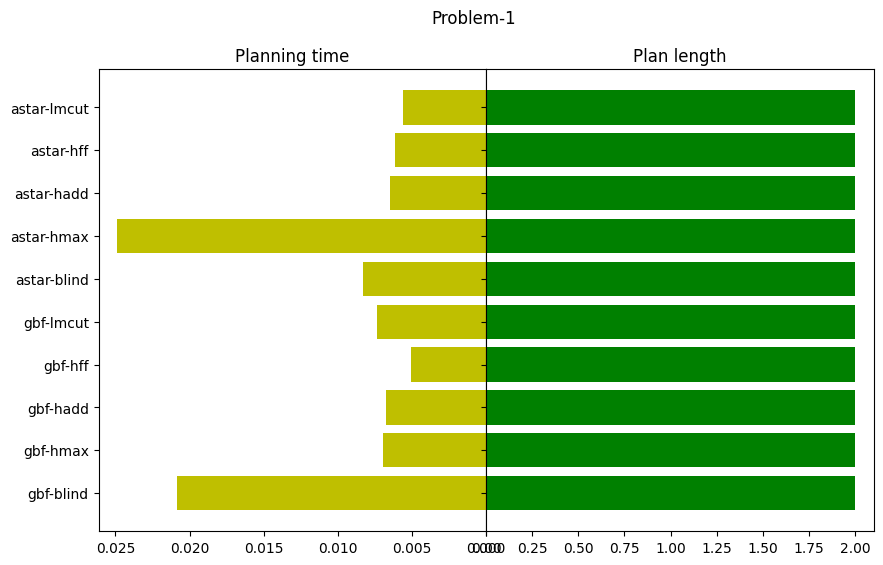

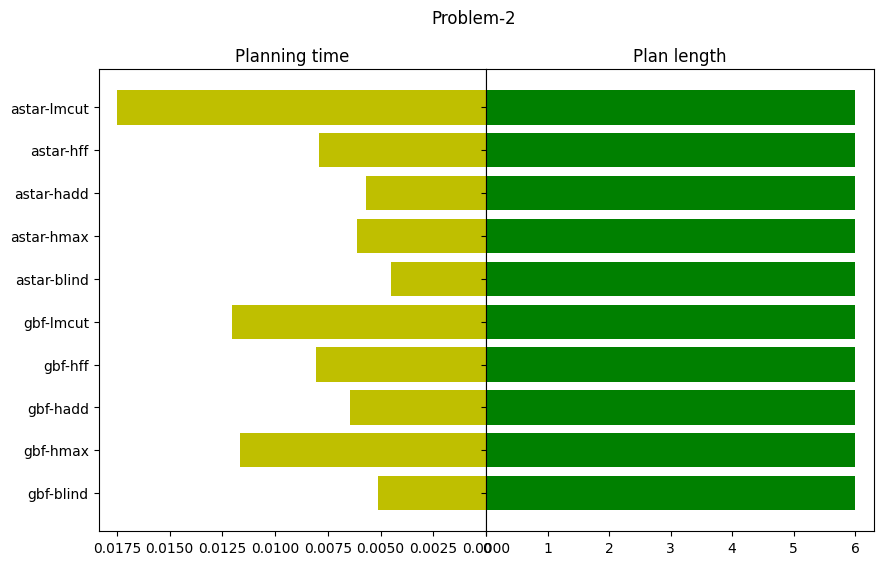

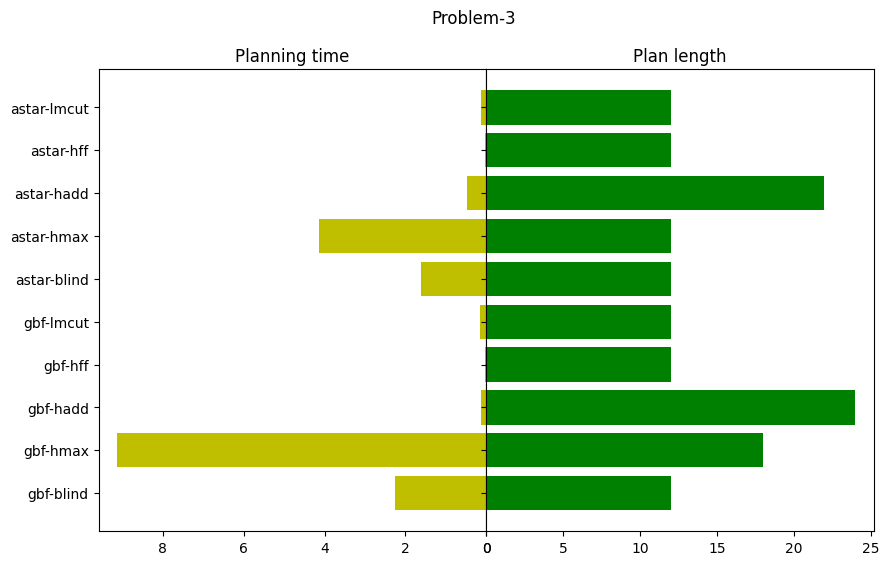

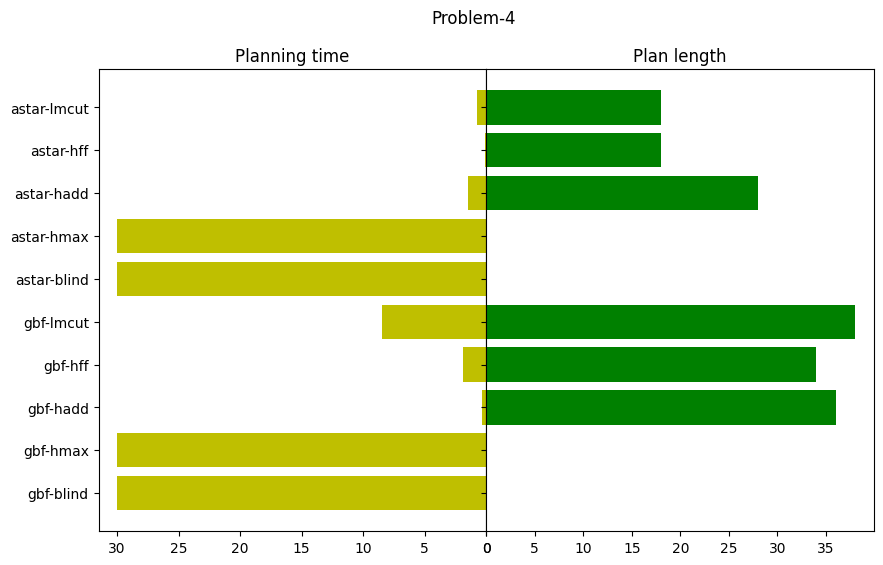

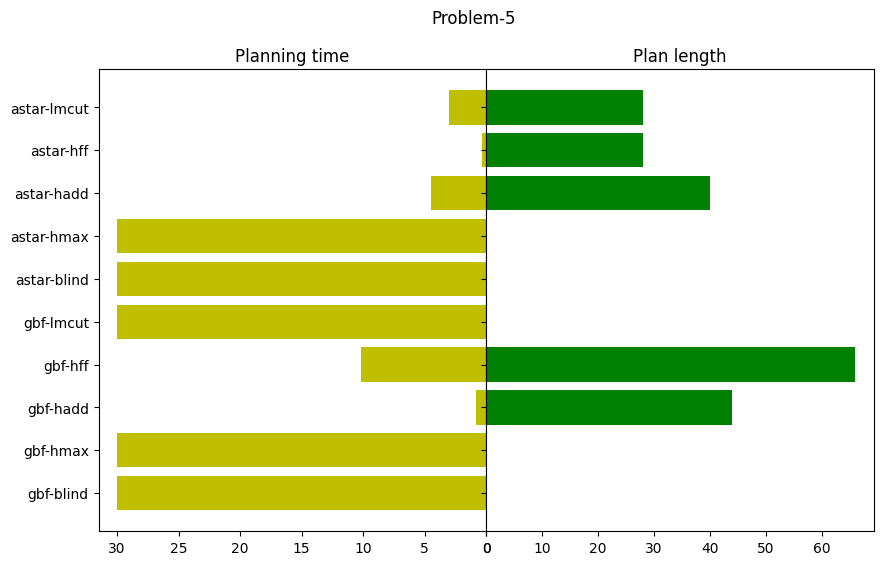

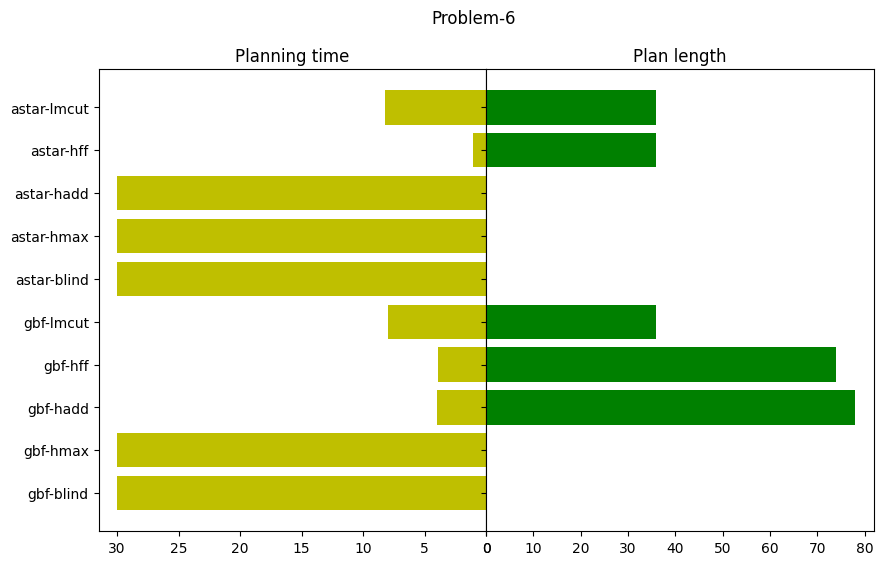

<module 'logging' from '/usr/lib/python3.10/logging/__init__.py'>

In [30]:
import itertools, sys, logging, importlib


def test_run_planning(domain_pddl_str,
                      problem_pddl_id,
                      search_alg_name,
                      heuristic_name,
                      save_dict=None):
    plan, run_time = run_planning(domain_pddl_str,
                                  BW_BLOCKS_PROBLEMS[problem_pddl_id - 1],
                                  search_alg_name,
                                  heuristic_name,
                                  return_time=True)
    print(f'Run time\t {run_time:.4f}\t Plan length\t {len(plan)}')
    save_dict[(search_alg_name, heuristic_name,
               problem_pddl_id)] = [run_time, len(plan)]
    return len(plan), run_time


def plot_result(result, timeout):
    import matplotlib.pyplot as plt
    all_problem_keys = result.keys()
    for problem_id in range(1, 7):
        problem_keys = [k for k in all_problem_keys if k[2] == problem_id]
        problem_keys_str = list(map(lambda x: f'{x[0]}-{x[1]}', problem_keys))
        bb = [
            result[k][0] if result[k][0] != -1 else timeout
            for k in problem_keys
        ]
        cc = [result[k][1] if result[k][0] != -1 else 0 for k in problem_keys]
        fig, axes = plt.subplots(figsize=(10, 6), ncols=2, sharey=True)
        axes[0].barh(problem_keys_str, bb, align='center', color='y')
        axes[1].barh(problem_keys_str, cc, align='center', color='g')
        axes[0].invert_xaxis()
        plt.subplots_adjust(wspace=0)

        axes[0].set(title='Planning time')
        axes[1].set(title='Plan length')
        fig.suptitle(f'Problem-{problem_id}')
        plt.show()


def test_all_combinations(timeout=5):
    import multiprocess as mp
    importlib.reload(logging)
    logging.basicConfig(level=logging.INFO,
                        handlers=[logging.StreamHandler(sys.stdout)])
    problem_id = [i for i in range(1, 7)]
    all_searchalgs = ['gbf', 'astar']
    all_heuristics = ['blind', 'hmax', 'hadd', 'hff', 'lmcut']
    result = {
        (j, k, i): [-1, -1]
        for (i, j,
             k) in itertools.product(problem_id, all_searchalgs, all_heuristics)
    }
    result_savers = []
    with mp.Manager() as manager:
        for problem_i, search_algo, heuristic in itertools.product(
                problem_id, all_searchalgs, all_heuristics):
            print(f'problem_{problem_i}', search_algo, heuristic)
            result_saver = manager.dict()
            result_savers.append(result_saver)
            planning_proc = mp.Process(target=test_run_planning,
                                       args=(BW_BLOCKS_DOMAIN, problem_i,
                                             search_algo, heuristic,
                                             result_saver))
            planning_proc.start()
            planning_proc.join(timeout=timeout)
            if planning_proc.is_alive():
                planning_proc.terminate()
                print(f'Terminate after {timeout} sec.')
                print()
                continue
            print()
        for res in result_savers:
            result.update(res)
    plot_result(result, timeout)


# Uncomment the following line, set timeout limit to plot results
test_all_combinations(timeout=30)
importlib.reload(logging)



Please identify which of these statement are True or False: 

1. Problems 1, 2 and 3 are easy (plan in less than 30 seconds) for all the methods.
2. Problem 4 is easy (plan in less than 30 seconds) for all the non-blind heuristics.
3. Problem 4 is easy (plan in less than 30 seconds) for all the non-blind heuristics, except `hmax`.
4. The `blind` heuristic is generally hopeless for the bigger problems.
5. `hadd` is generally much better (leads to faster planning) than `hmax`.
6. `gbf-lmcut` will always find paths of the same length as `astar-lmcut` (given sufficient time).
7. `astar-lmcut` will always find paths of the same length as `astar-hmax` (given sufficient time).
8. `astar-lmcut` usually finds paths of the same length as `astar-hff` (in these problems).
9. `gbf-hff` is a good compromise for planning speed and plan length (in these problems).

In [35]:
## Enter your answer by changing the assignment expression below, e.g., q10_answer = (True, False, True, ...)
## Your answer should be a tuple of 9 True / False values. 
q10_answer = (
    True,
    False,
    True,
    True,
    True, #maybe True
    False,
    True,
    True,
    True
    
)

In [36]:
# Test 10
Grader.run_single_test_inline(TestPSet4, "test_10", locals())

Test passed!!

.
----------------------------------------------------------------------
Ran 1 test in 0.007s

OK


# <a name="part4"></a> Time Spent on Pset (5 points)

Please use [this form](https://forms.gle/rDnyHdVXDm4gNAmC7) to tell us how long you spent on this pset. After you submit the form, the form will give you a confirmation word. Please enter that confirmation word below to get the 5 points. 

In [68]:
form_confirmation_word = "Eve"

In [69]:
# Run all tests
Grader.grade_output([TestPSet4], [locals()], "results.json")
Grader.print_test_results("results.json")

Test passed!!

Test passed!!

Test passed!!

Test passed!!

Test passed!!

Total score is 70/95.

Score for test_01_naive_search (principles_of_autonomy.notebook_tests.pset_4.TestPSet4) is 15/15.

Score for test_02_backtracking_search (principles_of_autonomy.notebook_tests.pset_4.TestPSet4) is 10/10.
- WA
NT
SA
Q
NSW
V
T
WA
NT
SA
NT
SA


Score for test_03_forward_checking (principles_of_autonomy.notebook_tests.pset_4.TestPSet4) is 20/20.
- WA
NT
SA
Q
NSW
V
T
{'SA': ['red'], 'NT': ['red']}
{'SA': ['green'], 'Q': ['green']}
{'NSW': ['blue'], 'Q': ['blue'], 'V': ['blue']}
{'NSW': ['red']}
{'V': ['green']}
{}
{}
WA
NT
SA
NT
SA
{'SA': ['red'], 'NT': ['red']}
None
{'SA': ['blue'], 'NT': ['blue']}
None


Score for test_04 (principles_of_autonomy.notebook_tests.pset_4.TestPSet4) is 0/5.
- Test Failed: Test requires a variable/function with the name q4_answer to be defined. Make sure you have not changed the name of this variable, and that the cell that defines it in your notebook has been run without producing errors.


Score for test_05 (principles_of_autonomy.noteb